### **Convolutional Neural Network (CNN)**

Convolutional Neural Networks (CNNs) are deep learning models designed to process data with a grid-like topology such as images. They are the foundation for most modern computer vision applications to detect features within visual data.

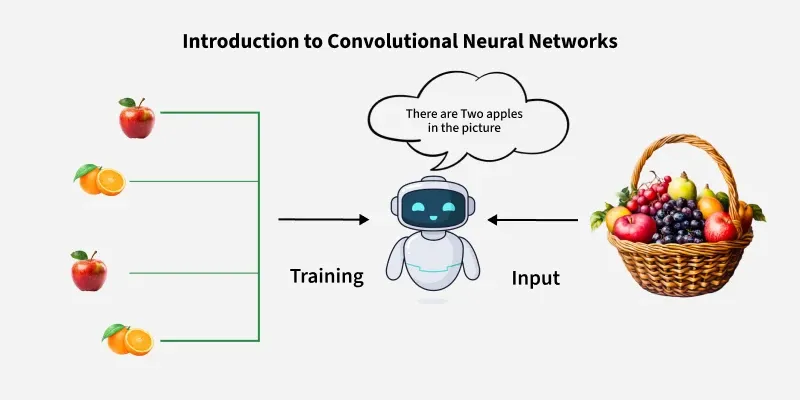

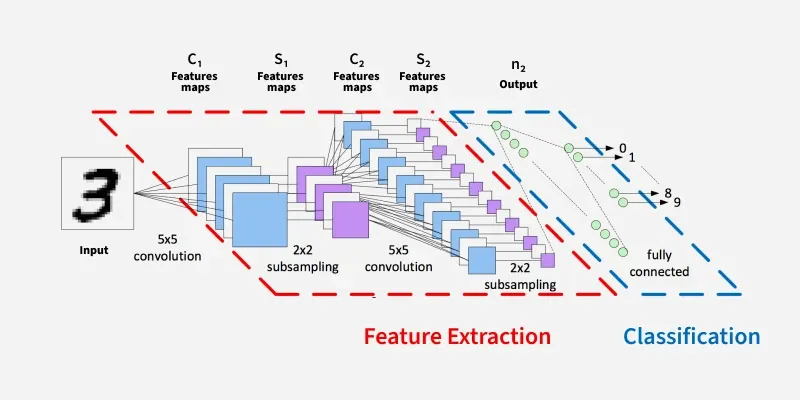

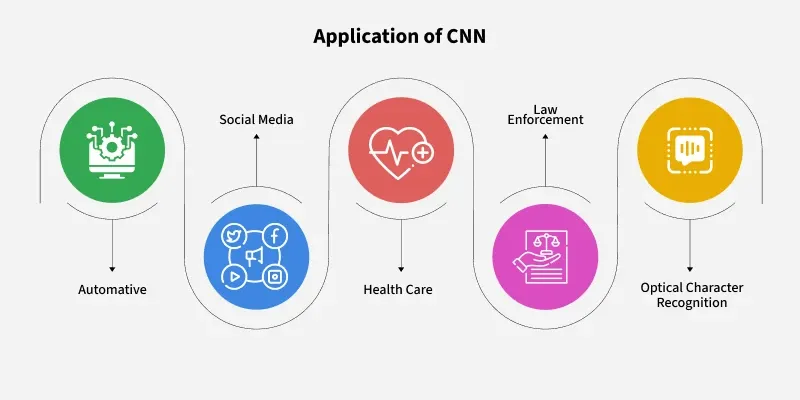

**Key Components**

**Convolutional Layers:** These layers apply convolutional operations to input images using filters or kernels to detect features such as edges, textures and more complex patterns. Convolutional operations help preserve the spatial relationships between pixels.

**Pooling Layers:** They downsample the spatial dimensions of the input, reducing the computational complexity and the number of parameters in the network. Max pooling is a common pooling operation where we select a maximum value from a group of neighboring pixels.

**Activation Functions:** They introduce non-linearity to the model by allowing it to learn more complex relationships in the data.

**Fully Connected Layers:** These layers are responsible for making predictions based on the high-level features learned by the previous layers. They connect every neuron in one layer to every neuron in the next layer.

**Convolution Layers**

Convolution layers are core components of CNNs used in image processing. They apply filters (kernels) over the input to extract important patterns and features.

Apply convolution operation using filters (kernels)

Perform element-wise multiplication and summation

Generate feature maps from input data

Detect patterns like edges, textures and shapes

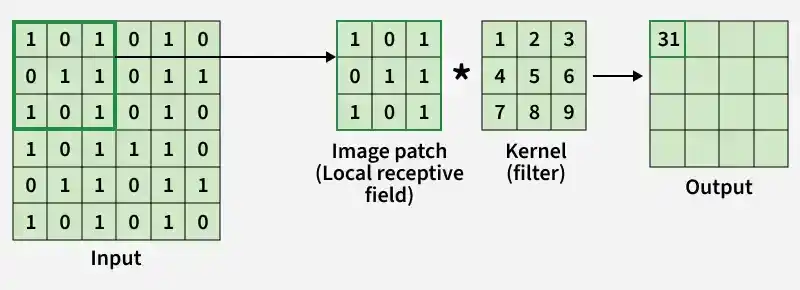

**Key Components of a Convolution Layer**

**1. Filters (Kernels)**

Small matrices that extract specific features from the input.

For example, one filter might detect horizontal edges while another detects vertical edges.

The values of filters are learned and updated during training.

**2. Stride**

Refers to the step size with which the filter moves across the input data.

Larger strides result in smaller output feature maps and faster computation.

**3. Padding**

Zeros or other values may be added around the input to control the spatial dimensions of the output.

Common types: "valid" (no padding) and "same" (pads output so feature map dimensions match input).

**4. Activation Function**

After convolution, a non-linear function like ReLU (Rectified Linear Unit) is often applied allowing the network to learn complex relationships in data.

Common activations: ReLU, Tanh, Leaky ReLU

**Types of Convolution Layers**

Different types of convolution layers are used based on the task and efficiency requirements.

2D Convolution (Conv2D): Most common for images; filters move across height and width

Depthwise Separable Convolution: Reduces computation by separating depthwise and pointwise operations

Dilated (Atrous) Convolution: Expands receptive field by adding gaps in the kernel without increasing computation

**Steps in a Convolution Layer**

Initialize Filters: Randomly initialize a set of filters with learnable parameters.

Convolve Filters with Input: Slide the filters across the width and height of the input data, computing the dot product between the filter and the input sub-region.

Apply Activation Function: Apply a non-linear activation function to the convolved output to introduce non-linearity.

Pooling (Optional): Often followed by a pooling layer (like max pooling) to reduce the spatial dimensions of the feature map and retain the most important information.

**Example Of Convolution Layer**

A convolution layer transforms input data into feature maps by applying multiple filters.

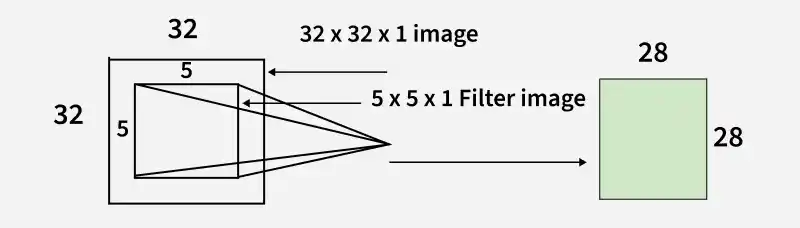

Input size: 32×32×3 (image with 3 channels)

Uses 10 filters of size 5×5, stride = 1, same padding

Output size: 32×32×10

Each filter captures different features from the image

**Pooling Layer**

A pooling layer is used to reduce the spatial dimensions (width and height) of feature maps while keeping the most important information.

Reduces size of feature maps (downsampling)

Applies a small filter over each region of the feature map

Summarizes values within the region (e.g., max or average)
 
Helps reduce computation and control overfitting

**Output Size Formula for Pooling Layer**

For a feature map with dimensions nh × nw × nc, the dimensions of the output after a pooling layer are:

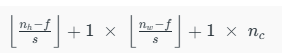

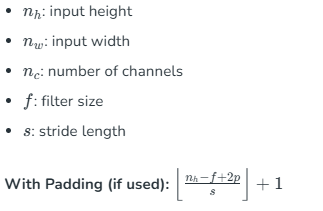

**Importance of Pooling Layers**

Pooling layers play a key role in making CNNs efficient and robust by simplifying feature maps while preserving important information.

Reduces dimensions, leading to faster computation and fewer parameters

Provides translation invariance, so small shifts do not affect output

Helps control overfitting and improves generalization

Focuses on important features and supports hierarchical learning

Example: A slightly shifted object (such as a cat) is still recognized

**Types of Pooling Layers**

**1. Max Pooling**

Max pooling selects the maximum value from each region of the feature map, capturing the most prominent features.

Selects the maximum value from each filter region

Retains important features like edges and textures

Reduces spatial dimensions of the feature map

Commonly used due to strong performance in practice

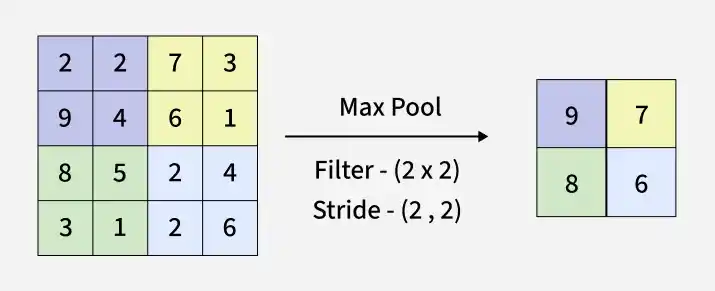

In [1]:
from tensorflow.keras.layers import MaxPooling2D
import numpy as np

feature_map = np.array([
    [1, 3, 2, 9],
    [5, 6, 1, 7],
    [4, 2, 8, 6],
    [3, 5, 7, 2]
]).reshape(1, 4, 4, 1)

max_pool = MaxPooling2D(pool_size=(2, 2), strides=2)
output = max_pool(feature_map)

print(output.numpy().reshape(2, 2))

[[6 9]
 [5 8]]


**2. Average Pooling**

Average pooling computes the mean value of elements within each region of the feature map, capturing overall feature information.

Calculates the average value from each filter region

Represents overall features rather than the strongest ones

Reduces spatial dimensions of the feature map

Produces smoother feature maps compared to max pooling

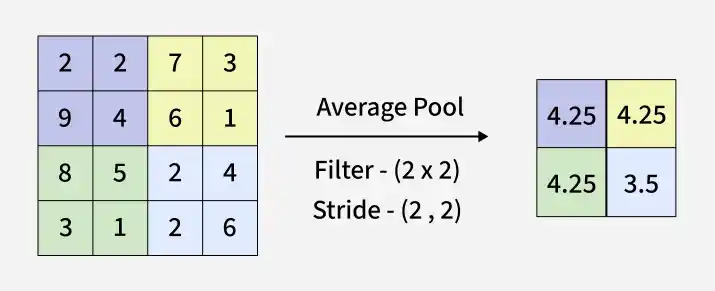

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.layers import AveragePooling2D

feature_map = np.array([
    [1, 3, 2, 9],
    [5, 6, 1, 7],
    [4, 2, 8, 6],
    [3, 5, 7, 2]
], dtype=np.float32).reshape(1, 4, 4, 1)  

avg_pool = AveragePooling2D(pool_size=(2, 2), strides=2)
output = avg_pool(feature_map)
print(output.numpy().reshape(2, 2))

**3. Global Pooling**

Global pooling reduces each channel of a feature map to a single value, resulting in a 1×1×nc output. This is equivalent to applying a filter of size nh × nw.  There are two types of global pooling:

Global Max Pooling: Takes the maximum value across the entire feature map.

Global Average Pooling: Computes the average of all values in the feature map.

In [ ]:
from tensorflow.keras.layers import GlobalMaxPooling2D, GlobalAveragePooling2D

feature_map = np.array([
    [1, 3, 2, 9],
    [5, 6, 1, 7],
    [4, 2, 8, 6],
    [3, 5, 7, 2]
], dtype=np.float32).reshape(1, 4, 4, 1) 

gm_pool = GlobalMaxPooling2D()
gm_output = gm_pool(feature_map)

ga_pool = GlobalAveragePooling2D()
ga_output = ga_pool(feature_map)

print("Global Max Pooling Output:", gm_output.numpy())
print("Global Average Pooling Output:", ga_output.numpy())

**Working of Pooling Layers**

Pooling layers reduce the size of feature maps by summarizing information within small regions.

Define a pooling window (e.g., 2×2) and stride

Slide the window across the input feature map

Apply operation (max or average) to each region

Produce a smaller, downsampled feature map

**Working of CNN**

**Input Image:** CNN receives an input image which is preprocessed to ensure uniformity in size and format.

**Convolutional Layers:** Filters are applied to the input image to extract features like edges, textures and shapes.

**Pooling Layers:** The feature maps generated by the convolutional layers are downsampled to reduce dimensionality.

**Fully Connected Layers:** The downsampled feature maps are passed through fully connected layers to produce the final output, such as a classification label.

**Output:** The CNN outputs a prediction, such as the class of the image.

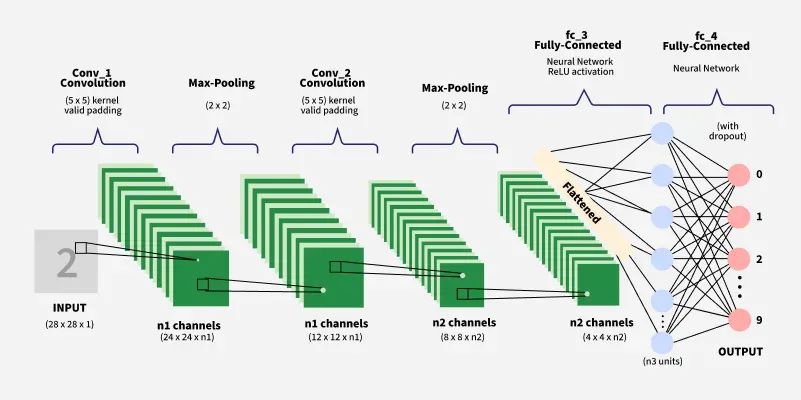

**Training a Convolutional Neural Network**

CNNs are trained using a supervised learning approach. This means that the CNN is given a set of labeled training images. The CNN learns to map the input images to their correct labels.

The training process for a CNN involves the following steps:

**Data Preparation:** The training images are preprocessed to ensure that they are all in the same format and size.

**Loss Function:** A loss function is used to measure how well the CNN is performing on the training data. The loss function is typically calculated by taking the difference between the predicted labels and the actual labels of the training images.

**Optimizer:** An optimizer is used to update the weights of the CNN in order to minimize the loss function.

**Backpropagation:** Backpropagation is a technique used to calculate the gradients of the loss function with respect to the weights of the CNN. The gradients are then used to update the weights of the CNN using the optimizer.

**How to Evaluate CNN Models**

Efficiency of CNN can be evaluated using a variety of criteria. Among the most popular metrics are:

**Accuracy:** Accuracy is the percentage of test images that the CNN correctly classifies.

**Precision:** Precision is the percentage of test images that the CNN predicts as a particular class and that are actually of that class.

**Recall:** Recall is the percentage of test images that are of a particular class and that the CNN predicts as that class.

**F1 Score:** The F1 Score is a harmonic mean of precision and recall. It is a good metric for evaluating the performance of a CNN on classes that are imbalanced.

**Applications**

Image classification: CNNs are the state-of-the-art models for image classification. They can be used to classify images into different categories such as cats and dogs.

Object detection: It can be used to detect objects in images such as people, cars and buildings. They can also be used to localize objects in images which means that they can identify the location of an object in an image.

Image segmentation: It can be used to segment images which means that they can identify and label different objects in an image. This is useful for applications such as medical imaging and robotics.

Video analysis: It can be used to analyze videos such as tracking objects in a video or detecting events in a video. This is useful for applications such as video surveillance and traffic monitoring.

**Advantages**

High Accuracy: They can achieve high accuracy in various image recognition tasks.

Efficiency: They are efficient, especially when implemented on GPUs.

Robustness: They are robust to noise and variations in input data.

Adaptability: It can be adapted to different tasks by modifying their architecture.

**Disadvantages**

Complexity: It can be complex and difficult to train, especially for large datasets.

Resource-Intensive: It require significant computational resources for training and deployment.

Data Requirements: They need large amounts of labeled data for training.

Interpretability: They can be difficult to interpret making it challenging to understand their predictions.